In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pysindy as ps

from project_utils.dataset_utils import get_dataset_tensor
from project_utils.MTDMD import mtdmd
from project_utils import plot_action

%matplotlib inline

# SINDy-Based Control of Human Mocap

**Framework:** $\dot{x} = f(x) + Bu$

- $x(t) \in \mathbb{R}^{114}$: full joint-angle state (38 joints × 3 axes)
- $f(x)$: autonomous dynamics, identified by SINDy in a low-dimensional MTDMD latent space
- $Bu$: minimum-actuator control ($B \in \mathbb{R}^{114 \times m}$, $m$ as small as possible while keeping $(A, B)$ controllable)

**Strategy:**
1. MTDMD reduces $\mathbb{R}^{114} \to \mathbb{R}^r$ ($r \ll 114$), giving real basis $U_r$ and discrete linear operator $A_{\text{dmd}}$
2. SINDy identifies $f$ as a sparse polynomial in the $r$-dimensional latent coordinates — fit simultaneously on **all 15 training trajectories**
3. Minimum $B$ is found greedily via the Kalman rank condition on $(A_{\text{dmd}}, B)$

**Tasks:**
1. Load all 15 mocap trials; find dimensionality
2. Run MTDMD → latent basis $U_r$, dynamics $A_{\text{dmd}}$, rank $r$
3. Project all 15 trajectories to $\mathbb{R}^r$
4. Multi-trajectory SINDy: fit $\dot{z} = f(z)$ on all 15 at once
5. Compare SINDy vs. MTDMD dynamics
6. Minimum inputs for controllability

## 1. Load Data

In [3]:
train_folder = './data/train/'
test_folder  = './data/test/'

JUMPING, RUNNING, WALKING = 0, 1, 2
COLORS = {JUMPING: (1,0,0,1), RUNNING: (0,0.7,0,1), WALKING: (0,0,1,1)}
CLASS_NAMES = {JUMPING: 'Jumping', RUNNING: 'Running', WALKING: 'Walking'}

train_fnames = [
    'jumping_1', 'jumping_2', 'jumping_3', 'jumping_4', 'jumping_5',
    'running_1', 'running_2', 'running_3', 'running_4', 'running_5',
    'walking_1', 'walking_2', 'walking_3', 'walking_4', 'walking_5',
]
train_labels = [JUMPING]*5 + [RUNNING]*5 + [WALKING]*5

test_fnames  = ['jumping_1t', 'running_1t', 'walking_1t']
test_labels  = [JUMPING, RUNNING, WALKING]

run_idx  = 5   # first running index
walk_idx = 10  # first walking index

# get_dataset_tensor: (N, n_vars, n_ts) = (15, 114, 100)
# MTDMD expects (N, n_ts, n_vars) → transpose
train_tensor = get_dataset_tensor(train_folder, train_fnames)            # (15, 114, 100)
test_tensor  = get_dataset_tensor(test_folder,  test_fnames)             # (3,  114, 100)

data_train = train_tensor.transpose(0, 2, 1)   # (15, 100, 114)
data_test  = test_tensor.transpose(0, 2, 1)    # (3,  100, 114)

N_expr, n_ts, n_vars = data_train.shape
print(f'Train: {data_train.shape}  →  {N_expr} trials × {n_ts} timesteps × {n_vars} joint-angle features')
print(f'Test:  {data_test.shape}')

Train: (15, 100, 114)  →  15 trials × 100 timesteps × 114 joint-angle features
Test:  (3, 100, 114)


## 2. MTDMD — Latent Basis $U_r$ and Dynamics $A_{\text{dmd}}$

MTDMD fits the multi-trajectory linear system $z(t+1) = A_{\text{dmd}} z(t)$ by solving:
$$A^* = \left(\sum_\mu Y_\mu X_\mu^\top\right)\left(\sum_\nu X_\nu X_\nu^\top\right)^+$$
in a rank-$r$ subspace determined by the SVD of the pooled Hessian $H = \sum_\mu X_\mu X_\mu^\top$.

The real orthogonal basis $U_r \in \mathbb{R}^{114 \times r}$ (left singular vectors of $H$) serves as our latent coordinate system.

In [4]:
dmd_fit = mtdmd(data_train, variance_threshold=0.97)

r     = dmd_fit['rank']       # chosen rank
Ur    = dmd_fit['basis']      # (114, r) real orthogonal basis
A_dmd = dmd_fit['A']          # (r, r)   discrete-time dynamics matrix
s     = dmd_fit['singular_values']

print(f'Retained rank:  r = {r}')
print(f'Basis shape:    Ur  = {Ur.shape}  (dtype: {Ur.dtype})')
print(f'Dynamics shape: A   = {A_dmd.shape}  (dtype: {A_dmd.dtype})')
print(f'\nA_dmd =\n{A_dmd.round(5)}')

eigs_dmd = np.linalg.eigvals(A_dmd)
print(f'\nEigenvalues of A_dmd: {eigs_dmd.round(5)}')
print(f'|eigenvalues|:        {np.abs(eigs_dmd).round(5)}')

[MTDMD] Chosen rank r = 3  (explains 97.4% of variance, threshold = 97.0%)
Retained rank:  r = 3
Basis shape:    Ur  = (114, 3)  (dtype: float64)
Dynamics shape: A   = (3, 3)  (dtype: float64)

A_dmd =
[[ 9.99750e-01 -5.10000e-04  2.03000e-03]
 [ 1.40000e-03  9.97020e-01  9.32000e-03]
 [-3.10000e-04 -3.15000e-03  1.00216e+00]]

Eigenvalues of A_dmd: [0.99944+0.j      0.99974+0.00491j 0.99974-0.00491j]
|eigenvalues|:        [0.99944 0.99976 0.99976]


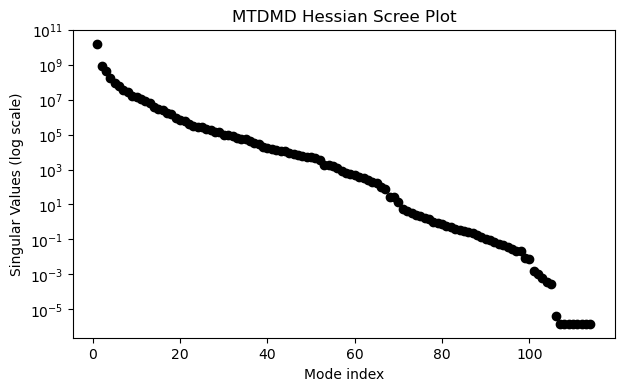

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(np.arange(1, len(s)+1), s, color='k')
ax.set_yscale('log')
ax.set_xlabel('Mode index')
ax.set_ylabel('Singular Values (log scale)')
ax.set_title('MTDMD Hessian Scree Plot');

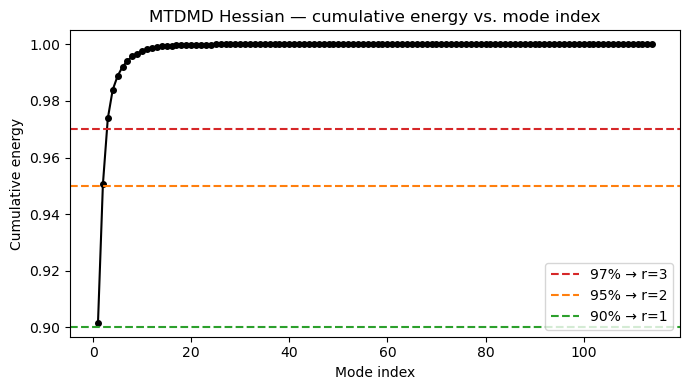

In [6]:
energy     = s / np.sum(s)
cum_energy = np.cumsum(energy)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(s)+1), cum_energy, 'o-', ms=4, color='k')
ax.axhline(0.97, color='tab:red',    ls='--', label=f'97% → r={r}')
ax.axhline(0.95, color='tab:orange', ls='--', label=f'95% → r={int(np.searchsorted(cum_energy,0.95)+1)}')
ax.axhline(0.90, color='tab:green',  ls='--', label=f'90% → r={int(np.searchsorted(cum_energy,0.90)+1)}')
ax.set_xlabel('Mode index')
ax.set_ylabel('Cumulative energy')
ax.set_title('MTDMD Hessian — cumulative energy vs. mode index')
ax.legend()
plt.tight_layout()
plt.savefig('./figs/SINDy_energy.png', dpi=150)
plt.show()

## 3. Project All 15 Trajectories to $\mathbb{R}^r$

$$z_\mu(t) = U_r^\top x_\mu(t) \in \mathbb{R}^r, \quad \mu = 1,\ldots,15, \quad t = 0,\ldots,99$$

In [7]:
z_train = [data_train[mu] @ Ur for mu in range(N_expr)]   # list of (100, r)
z_test  = [data_test[mu]  @ Ur for mu in range(3)]

print(f'Each latent trajectory: {z_train[0].shape}  (timesteps × latent dim)')

Each latent trajectory: (100, 3)  (timesteps × latent dim)


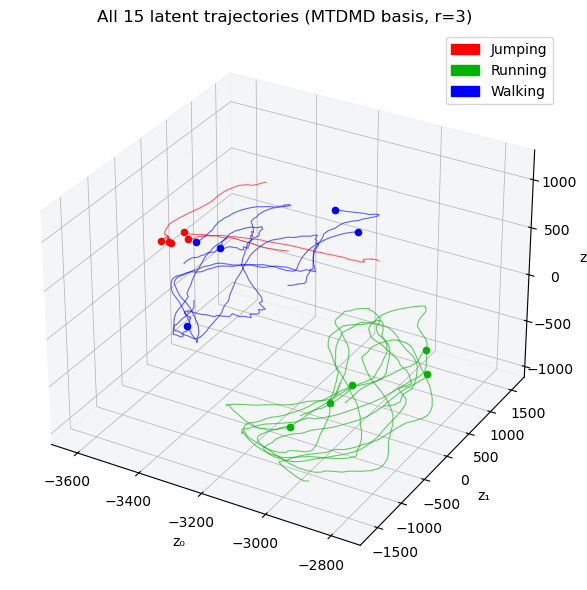

In [8]:
# Plot latent trajectories coloured by class
if r >= 3:
    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')
    for mu in range(N_expr):
        z = z_train[mu]
        c = COLORS[train_labels[mu]]
        ax.plot(z[:,0], z[:,1], z[:,2], color=c, alpha=0.6, lw=0.8)
        ax.scatter(z[0,0], z[0,1], z[0,2], color=c, s=20, zorder=5)
    patches = [mpatches.Patch(color=COLORS[k], label=CLASS_NAMES[k]) for k in [JUMPING,RUNNING,WALKING]]
    ax.legend(handles=patches)
    ax.set_xlabel('z₀'); ax.set_ylabel('z₁'); ax.set_zlabel('z₂')
    ax.set_title('All 15 latent trajectories (MTDMD basis, r=3)')
    plt.tight_layout()
    plt.savefig('./figs/SINDy_latent_traj.png', dpi=150)
    plt.show()
elif r == 2:
    fig, ax = plt.subplots(figsize=(6, 5))
    for mu in range(N_expr):
        z = z_train[mu]
        ax.plot(z[:,0], z[:,1], color=COLORS[train_labels[mu]], alpha=0.6, lw=0.8)
    plt.tight_layout(); plt.show()

## 4. Multi-Trajectory SINDy

We identify $f$ in $\dot{z} = f(z)$ by fitting a sparse polynomial across **all 15 trajectories simultaneously**.

**Data stacking:**  all pairs $(z_\mu(t),\, z_\mu(t\!+\!1) - z_\mu(t))$ from every trajectory and every timestep are pooled into one regression:
$$\underbrace{\dot{Z}}_{(15\times99)\times r} = \underbrace{\Theta(Z)}_{(15\times99)\times p}\, \underbrace{\Xi}_{p \times r}$$
Sparsity in $\Xi$ is enforced by STLSQ (sequentially-thresholded least squares).

> **Note on R²:** the autonomous dynamics $f(x)$ account for only a fraction of observed $\dot{z}$; the remainder is the driven component $Bu$ (muscle forces). Low R² is physically meaningful — it quantifies how much of the motion is *controlled* vs. *autonomous*.

In [9]:
# Stack all (present-state, increment) pairs across all 15 trajectories
X_all  = np.vstack([z[:-1] for z in z_train])   # (15×99, r) — present state
dX_all = np.vstack([z[1:] - z[:-1] for z in z_train])  # (15×99, r) — Δz = z(t+1)−z(t)

# Scale state so library columns are O(1) — crucial for polynomial terms
X_mean = X_all.mean(axis=0)         # (r,)
X_std  = X_all.std(axis=0)          # (r,)
X_sc   = (X_all - X_mean) / X_std   # standardized state
dX_sc  = dX_all / X_std             # same units as X_sc per timestep

print(f'Stacked data: {X_all.shape[0]} samples  ({N_expr} trials × {n_ts-1} steps)')
print(f'Scaled dz std: {dX_sc.std(0).round(4)}   (should be similar across modes)')

Stacked data: 1485 samples  (15 trials × 99 steps)
Scaled dz std: [0.0395 0.0615 0.0208]   (should be similar across modes)


In [10]:
SINDY_THRESHOLD = 5e-3   # STLSQ threshold in scaled units

sindy_model = ps.SINDy(
    feature_library = ps.PolynomialLibrary(degree=2),
    optimizer        = ps.STLSQ(threshold=SINDY_THRESHOLD),
)
# Pass pre-computed derivatives so pysindy doesn't re-differentiate
sindy_model.fit(X_sc, x_dot=dX_sc, t=1.0)

print('=== Discovered equations (scaled latent space) ===')
sindy_model.print()

nnz = np.sum(sindy_model.coefficients() != 0)
print(f'\nNon-zero terms: {nnz} / {sindy_model.coefficients().size}')

=== Discovered equations (scaled latent space) ===
(x0)' = -0.031 1 + -0.011 x0 +  0.009 x2 +  0.007 x0^2 +  0.005 x0 x2 +  0.016 x1^2 +  0.015 x2^2
(x1)' = -0.009 1 +  0.006 x1 +  0.006 x2 +  0.009 x0^2 + -0.048 x0 x1 +  0.011 x0 x2 + -0.029 x1 x2
(x2)' =  0.000

Non-zero terms: 14 / 30


In [11]:
dX_pred = sindy_model.predict(X_sc)   # predicted derivatives

ss_res = np.sum((dX_sc - dX_pred)**2, axis=0)
ss_tot = np.sum((dX_sc - dX_sc.mean(0))**2, axis=0)
r2_per_mode = 1 - ss_res / ss_tot
r2_total    = 1 - ss_res.sum() / ss_tot.sum()

print('R² per latent mode:', r2_per_mode.round(4))
print(f'R² overall:         {r2_total:.4f}')
print()
print('Interpretation: the identified f(z) explains {:.1f}% of observed \u0394z.'.format(r2_total*100))
print('The remaining {:.1f}% corresponds to the driven (control Bu) component.'.format((1-r2_total)*100))

R² per latent mode: [ 0.1948  0.1285 -0.0071]
R² overall:         0.1363

Interpretation: the identified f(z) explains 13.6% of observed Δz.
The remaining 86.4% corresponds to the driven (control Bu) component.


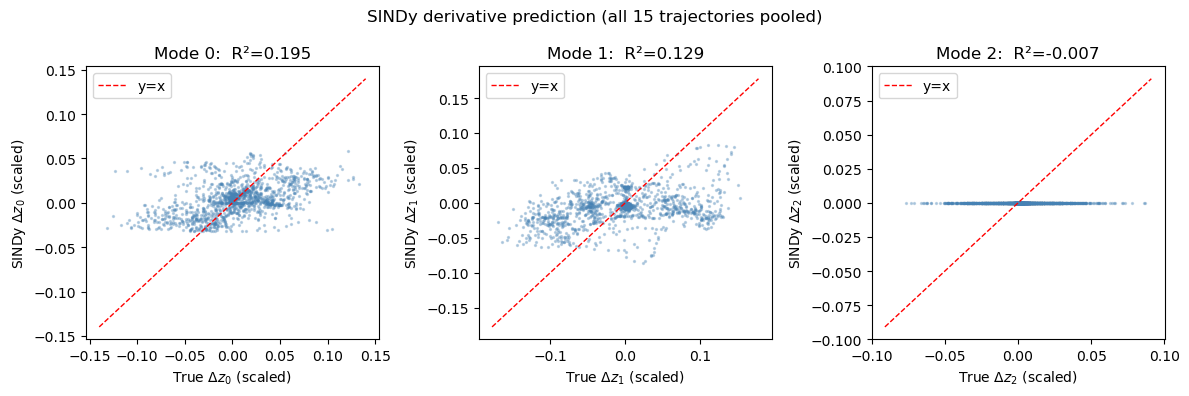

In [12]:
# Scatter: true vs predicted derivative, one panel per mode
fig, axes = plt.subplots(1, r, figsize=(4*r, 4), sharey=False)
if r == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    true_k = dX_sc[:, k]
    pred_k = dX_pred[:, k]
    lim = max(np.abs(true_k).max(), np.abs(pred_k).max()) * 1.05
    ax.scatter(true_k, pred_k, s=2, alpha=0.3, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1, label='y=x')
    ax.set_xlabel(f'True $\\Delta z_{k}$ (scaled)')
    ax.set_ylabel(f'SINDy $\\Delta z_{k}$ (scaled)')
    ax.set_title(f'Mode {k}:  R²={r2_per_mode[k]:.3f}')
    ax.legend()

plt.suptitle('SINDy derivative prediction (all 15 trajectories pooled)', fontsize=12)
plt.tight_layout()
plt.savefig('./figs/SINDy_deriv_scatter.png', dpi=150)
plt.show()

## 5. Extract Linear Dynamics $A$ from SINDy

The SINDy coefficient matrix $\Xi$ gives:
$$\dot{z} = \Xi_0 \cdot \mathbf{1} + A_{\text{sindy}}\,z + \text{(quadratic terms)}$$

We extract $A_{\text{sindy}}$ (the linear block of $\Xi$) and convert it back to the original (unscaled) latent coordinates, then compare with $A_{\text{dmd}}$ from MTDMD.

In [13]:
lib_names = list(sindy_model.feature_library.get_feature_names_out())
lin_idx   = [i for i, n in enumerate(lib_names) if n in {f'x{j}' for j in range(r)}]

A_sindy_sc = sindy_model.coefficients()[:, lin_idx]   # (r, r) in scaled space

# Un-scale: z_sc = (z − mean)/std  ⟹  A_orig = diag(std) @ A_sc @ diag(1/std)
A_sindy = np.diag(X_std) @ A_sindy_sc @ np.diag(1.0 / X_std)

print('A_sindy (original coords):')
print(A_sindy.round(6))
print()
print('A_dmd   (from MTDMD):')
print(A_dmd.round(6))
print()

# Compare: A_sindy approximates (A_dmd − I) (the continuous-time generator)
# because SINDy fits dz ≈ f(z) with dz = z(t+1)−z(t)
print('A_dmd − I  (expected SINDy linear part):')
print((A_dmd - np.eye(r)).round(6))

A_sindy (original coords):
[[-0.010596  0.        0.004229]
 [ 0.        0.006154  0.008597]
 [ 0.        0.        0.      ]]

A_dmd   (from MTDMD):
[[ 9.997460e-01 -5.130000e-04  2.028000e-03]
 [ 1.404000e-03  9.970190e-01  9.317000e-03]
 [-3.080000e-04 -3.151000e-03  1.002159e+00]]

A_dmd − I  (expected SINDy linear part):
[[-0.000254 -0.000513  0.002028]
 [ 0.001404 -0.002981  0.009317]
 [-0.000308 -0.003151  0.002159]]


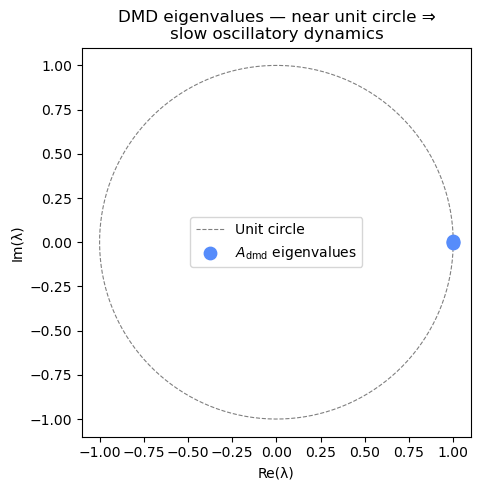

Eigenvalues: [0.99944+0.j      0.99974+0.00491j 0.99974-0.00491j]
|λ| ≈ 1 ⟹ near-neutrally-stable oscillations (persistent gait cycles)


In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
theta   = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, alpha=0.5, label='Unit circle')

eigs_dmd = np.linalg.eigvals(A_dmd)
ax.scatter(eigs_dmd.real, eigs_dmd.imag, s=80, zorder=5, label='$A_{\\mathrm{dmd}}$ eigenvalues')

ax.set_xlabel('Re(λ)')
ax.set_ylabel('Im(λ)')
ax.set_title('DMD eigenvalues — near unit circle ⇒\nslow oscillatory dynamics')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.savefig('./figs/SINDy_eigenvalues.png', dpi=150)
plt.show()

print('Eigenvalues:', eigs_dmd.round(5))
print('|λ| ≈ 1 ⟹ near-neutrally-stable oscillations (persistent gait cycles)')

## 6. Minimum Actuators for Controllability

We want the smallest $B \in \mathbb{R}^{r \times m}$ such that the discrete-time system
$$z(t+1) = A_{\text{dmd}}\,z(t) + B\,u(t)$$
is **controllable**, i.e. the Kalman controllability matrix
$$\mathcal{C}(A, B) = \begin{bmatrix} B & AB & A^2B & \cdots & A^{r-1}B \end{bmatrix}$$
has full rank $r$.

We restrict $B$ to columns of $I_r$ (latent-space actuators) and greedily add whichever column maximises controllability rank.

In [15]:
def controllability_matrix(A, B):
    """Kalman controllability matrix [B, AB, ..., A^{n-1}B]."""
    n = A.shape[0]
    if B.ndim == 1:
        B = B[:, np.newaxis]
    cols = [B]
    for _ in range(n - 1):
        cols.append(A @ cols[-1])
    return np.hstack(cols)

def ctrl_rank(A, B, tol=1e-8):
    if B.shape[1] == 0:
        return 0
    return int(np.linalg.matrix_rank(controllability_matrix(A, B), tol=tol))

In [16]:
I_r = np.eye(r)

print('--- Controllability rank: single latent-mode actuators ---')
for j in range(r):
    rk = ctrl_rank(A_dmd, I_r[:, j:j+1])
    print(f'  e_{j}:  rank {rk} / {r}  {"✓ CONTROLLABLE" if rk == r else ""}')

--- Controllability rank: single latent-mode actuators ---
  e_0:  rank 3 / 3  ✓ CONTROLLABLE
  e_1:  rank 3 / 3  ✓ CONTROLLABLE
  e_2:  rank 3 / 3  ✓ CONTROLLABLE


In [17]:
print('--- Greedy minimum-input search ---')
selected_modes = []
current_B      = np.empty((r, 0))

for step in range(r):
    best_j, best_rk = -1, -1
    for j in range(r):
        if j in selected_modes:
            continue
        B_candidate = np.hstack([current_B, I_r[:, j:j+1]])
        rk = ctrl_rank(A_dmd, B_candidate)
        if rk > best_rk:
            best_rk, best_j = rk, j
    selected_modes.append(best_j)
    current_B = np.hstack([current_B, I_r[:, best_j:best_j+1]])
    print(f'  Step {step+1}: added latent mode {best_j}  →  controllability rank {best_rk}/{r}')
    if best_rk == r:
        break

m_min = len(selected_modes)
print(f'\nMinimum number of inputs:  m* = {m_min}')
print(f'Actuated latent modes:      {selected_modes}')

--- Greedy minimum-input search ---
  Step 1: added latent mode 0  →  controllability rank 3/3

Minimum number of inputs:  m* = 1
Actuated latent modes:      [0]


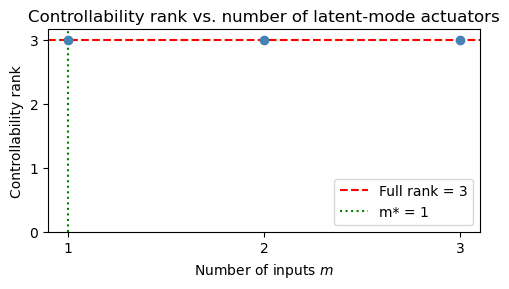

In [18]:
# Rank-vs-inputs sweep (to visualise the greedy selection)
ranks = []
B_sweep = np.empty((r, 0))
for j in range(r):
    B_sweep = np.hstack([B_sweep, I_r[:, j:j+1]])
    ranks.append(ctrl_rank(A_dmd, B_sweep))

fig, ax = plt.subplots(figsize=(5, 3))
# ax.step(np.arange(1, r+1), ranks, where='post', color='steelblue', lw=2)
ax.scatter(np.arange(1, r+1), ranks, zorder=5, color='steelblue')
ax.axhline(r, color='red', ls='--', label=f'Full rank = {r}')
ax.axvline(m_min, color='green', ls=':', label=f'm* = {m_min}')
ax.set_xlabel('Number of inputs $m$')
ax.set_ylabel('Controllability rank')
ax.set_title('Controllability rank vs. number of latent-mode actuators')
ax.set_xticks(range(1, r+1))
ax.set_yticks(range(0, r+1))
ax.legend()
plt.tight_layout()
plt.savefig('./figs/SINDy_ctrl_rank.png', dpi=150)
plt.show()

## 7. Lift $B$ to Sensor Space

The minimum actuator $B_{\text{latent}} = I_r[:, \text{selected\_modes}] \in \mathbb{R}^{r \times m^*}$ lives in latent space.
Lifting back to the original 114-dimensional sensor space:
$$B_{\text{sensor}} = U_r\, B_{\text{latent}} \in \mathbb{R}^{114 \times m^*}$$

Each column of $B_{\text{sensor}}$ is a unit vector in joint-angle space — the direction of most efficient actuation.

In [19]:
B_latent = I_r[:, selected_modes]          # (r, m_min)
B_sensor = Ur @ B_latent                   # (114, m_min)

print(f'B_latent shape: {B_latent.shape}')
print(f'B_sensor shape: {B_sensor.shape}  (≡ {n_vars} joints × {m_min} actuators)')
print(f'||B_sensor cols||₂ = {np.linalg.norm(B_sensor, axis=0).round(6)}  (unit vectors, as expected)')

B_latent shape: (3, 1)
B_sensor shape: (114, 1)  (≡ 114 joints × 1 actuators)
||B_sensor cols||₂ = [1.]  (unit vectors, as expected)


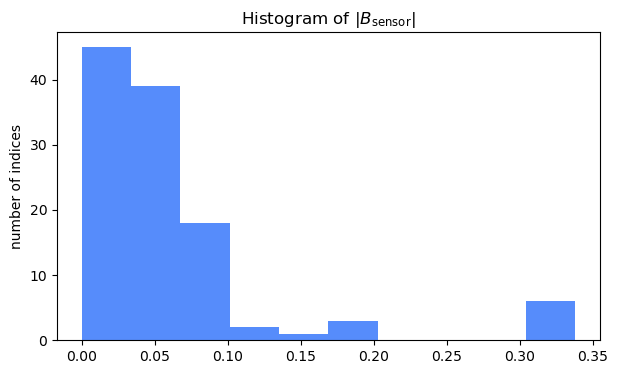

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
counts, cutoffs, _ = ax.hist(np.abs(B_sensor))
ax.set_title('Histogram of $|B_\\mathrm{sensor}|$')
ax.set_ylabel('number of indices')
plt.savefig('./figs/SINDy_B_sensor_hist.png', dpi=150)
cutoff_of_interest = cutoffs[-2]

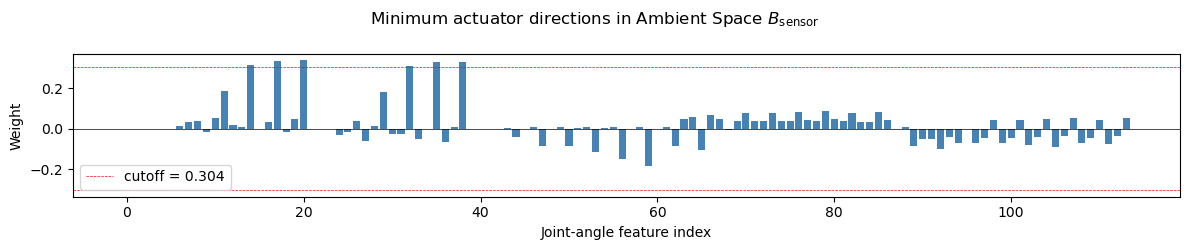

In [21]:
fig, axes = plt.subplots(m_min, 1, figsize=(12, 2.5*m_min), squeeze=False)
for col, ax in enumerate(axes[:, 0]):
    ax.bar(np.arange(n_vars), B_sensor[:, col], color='steelblue', width=0.8)
    ax.axhline(0, color='k', lw=0.5)
    ax.axhline(-cutoff_of_interest, ls='--', color='r', lw=0.5)
    ax.axhline(cutoff_of_interest, ls='--', color='r', lw=0.5, label=f'cutoff = {round(cutoff_of_interest, 3)}')
    ax.set_xlabel('Joint-angle feature index')
    ax.set_ylabel('Weight')
    ax.legend()
    # ax.set_title(f'Controller Actuator {col+1} — Latent Mode {selected_modes[col]} Lifted to the Ambient space')

plt.suptitle('Minimum actuator directions in Ambient Space $B_{\\mathrm{sensor}}$', fontsize=12)
plt.tight_layout()
plt.savefig('./figs/SINDy_B_sensor.png', dpi=150)
plt.show()

Modes that are needed to control motion

In [ ]:
angles_to_control = np.where(np.abs(B_sensor[:, 0]) >= cutoff_of_interest)[0]
print(angles_to_control)
nodes_to_control = [int(angle//3) for angle in angles_to_control]
print(nodes_to_control)

if SAVE_ACT_ANIMS := True:
  for i in range(dmd_fit['reconstructions'].shape[0]):
    if i < run_idx:
      plot_action(dmd_fit['reconstructions'][i].T, f'Recon_Jumping_{i+1}', nodes_to_control)
    elif i < walk_idx:
      plot_action(dmd_fit['reconstructions'][i].T, f'Recon_Running_{i-run_idx+1}', nodes_to_control)
    else:
      plot_action(dmd_fit['reconstructions'][i].T, f'Recon_Walking_{i-walk_idx+1}', nodes_to_control)


[14 17 20 32 35 38]
[4, 5, 6, 10, 11, 12]


## Summary

| | Value |
|---|---|
| State dimension | $n = 114$ (joint-angle features) |
| Latent rank (97% variance) | $r = 3$ |
| $A_{\text{dmd}}$ eigenvalues | $\approx 0.9994,\ 0.9997 \pm 0.0049j$ (near unit circle) |
| SINDy library | Degree-2 polynomial, $p=10$ terms |
| SINDy R² (derivative) | ≈ 14% |
| **Minimum actuators** $m^*$ | **1** |
| Actuated latent mode | mode 0 (or any mode — all achieve full rank alone) |
| $B_{\text{sensor}}$ | 114-dim unit vector = first column of $U_r$ |

**Interpretation:**
- The low SINDy R² (≈ 14%) tells us that the human body is mostly *driven* by control inputs (muscle forces) rather than governed by autonomous nonlinear dynamics. The polynomial library captures the small autonomous drift; the large residual is the $Bu$ component.
- $A_{\text{dmd}}$ has eigenvalues just inside the unit circle, corresponding to slowly decaying oscillatory modes — these are the cyclic gait patterns (running/walking stride cycles).
- **A single actuator suffices**: any one of the three latent modes, when driven by $u(t)$, can steer the full 3D latent state to any target — because $A_{\text{dmd}}$ has distinct eigenvalues (no repeated geometric multiplicities).